In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
import statsmodels.api as sm
random_state = 45


**1---Data Inspection**

In [2]:
df = pd.read_csv('data/train.csv')
print('---raw data---')
display(df.head())
print('---raw data shape---')
display(df.shape)
print('---data info---')
display(df.info())
print('---data description---')
display(df.describe().T)

---raw data---


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---raw data shape---


(1460, 81)

---data info---
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Ove

None

---data description---


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


**2--Renaming the columns for uniformatiy**

In [3]:
df = df.rename(columns = {i:i.lower() for i in df.columns})
df.head()

,id,mssubclass,mszoning,lotfrontage,lotarea,street,alley,lotshape,landcontour,utilities,...,poolarea,poolqc,fence,miscfeature,miscval,mosold,yrsold,saletype,salecondition,saleprice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


**3--Suspicious types to flag**

In [4]:
print('--mssubclass represents the class of sold property in real-state--\n but here its represented as an integer\n --must be transfered into nominal category, as it represents category of sold property based on style, architecture,..--')
display(df['mssubclass'].unique())
print('--mosold represents the month when the property was sold--\n which is represented as an integer\n --must be transfered into nominal category, as it represents category of month--')
display(df['mosold'].unique())
df['mssubclass']=df['mssubclass'].astype(str)
df['mosold']=df['mosold'].astype(str)

--mssubclass represents the class of sold property in real-state--
 but here its represented as an integer
 --must be transfered into nominal category, as it represents category of sold property based on style, architecture,..--


array([ 60,  20,  70,  50, 190,  45,  90, 120,  30,  85,  80, 160,  75,
       180,  40])

--mosold represents the month when the property was sold--
 which is represented as an integer
 --must be transfered into nominal category, as it represents category of month--


array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6])

**Classification into numeric, categoric, continuous and discrete datas**

In [5]:
df_raw = df.copy()
df_raw = df_raw.drop(columns=['id'])  #dropping the id column
def classify(df):
    target = 'saleprice'
    numerical = [c for c in df.select_dtypes(include=np.number).columns if c!=target]
    categorical = [c for c in df.select_dtypes(exclude=np.number).columns if c!=target]
    continuous = [feature for feature in numerical if df[feature].nunique()>20]
    discrete = [feature for feature in numerical if df[feature].nunique()<=20]
    return numerical, categorical, continuous, discrete
numerical, categorical, continuous, discrete = classify(df_raw)
print(f'The numerical features are: {numerical}\n')
print(f'The categorical features are: {categorical}\n')
print(f'The continuous features are: {continuous}\n')
print(f'The discrete features are: {discrete}\n')

The numerical features are: ['lotfrontage', 'lotarea', 'overallqual', 'overallcond', 'yearbuilt', 'yearremodadd', 'masvnrarea', 'bsmtfinsf1', 'bsmtfinsf2', 'bsmtunfsf', 'totalbsmtsf', '1stflrsf', '2ndflrsf', 'lowqualfinsf', 'grlivarea', 'bsmtfullbath', 'bsmthalfbath', 'fullbath', 'halfbath', 'bedroomabvgr', 'kitchenabvgr', 'totrmsabvgrd', 'fireplaces', 'garageyrblt', 'garagecars', 'garagearea', 'wooddecksf', 'openporchsf', 'enclosedporch', '3ssnporch', 'screenporch', 'poolarea', 'miscval', 'yrsold']

The categorical features are: ['mssubclass', 'mszoning', 'street', 'alley', 'lotshape', 'landcontour', 'utilities', 'lotconfig', 'landslope', 'neighborhood', 'condition1', 'condition2', 'bldgtype', 'housestyle', 'roofstyle', 'roofmatl', 'exterior1st', 'exterior2nd', 'masvnrtype', 'exterqual', 'extercond', 'foundation', 'bsmtqual', 'bsmtcond', 'bsmtexposure', 'bsmtfintype1', 'bsmtfintype2', 'heating', 'heatingqc', 'centralair', 'electrical', 'kitchenqual', 'functional', 'fireplacequ', 'gara

**4-- Data Quality Assessment**

**Checking null-values, duplicate values and constant/quasi-constant features.**

In [6]:

data_report = pd.DataFrame(
    {
        'null_count':df_raw.isna().sum(),  #counting the total number of null values in each feature
        'null_percentage':(df.isna().mean() * 100).round(2)  #and converting them into percentage based on whole training examples
    }
).query('null_count>0').sort_values('null_percentage',ascending=False) #only selecting the datas having null values greater than 0 and sorting them in descending order based on null percentage
print('---The report on null values and null percentage based on every features having null values---')
display(data_report)

print('---The number of features having duplicate values---')
display(df_raw.duplicated().sum())


---The report on null values and null percentage based on every features having null values---


,null_count,null_percentage
poolqc,1453.0,99.52
miscfeature,1406.0,96.30
alley,1369.0,93.77
fence,1179.0,80.75
masvnrtype,872.0,59.73
fireplacequ,690.0,47.26
lotfrontage,259.0,17.74
garageyrblt,81.0,5.55
garagetype,81.0,5.55
garagefinish,81.0,5.55


---The number of features having duplicate values---


np.int64(0)

**INTERPRETATON**

**From the above report, we can come up with following conclusions**

.electrical null means, there is dataentry mistake cause every house has electricity,--> REPLACE WITH MODE VALUE

.Based on the categorical features having null value, it means the house doesnot has this feature,--> REPLACE WITH NONE

.Based on the numerical features having null value, it means the house doesnot has this feature,--> REPLACE WITH 0

.But for the feature such as lotfrontage, null value means the mistake in dataentry, cause every house built has lotfrontage,--> REPLACE WITH THE MEDIAN


**Checking for constant | near constant features**

In [7]:
#FOR NUMERICAL FEAUTURES
vt = VarianceThreshold(threshold=0.01)     #assigning the threshold for variance of 0.01 meaning the variance in the values of the training datas must be greater than 0.01 to not be considered as constant features
vt.fit(df_raw[numerical].fillna(0))       #Checking variation of every numerical features
variance_result = vt.get_support()       
constant_numerical_features = [col for col,s in zip(df_raw[numerical],variance_result) if not s]   #if the variation of the feature in every training datas is less than the threshold then we assume the feature as constant feature
print(f'Numerical Features having constant variation in values {constant_numerical_features}')

Numerical Features having constant variation in values []


In [8]:
#FOR CATEGORICAL FEATURES
#here iloc[0] represents the value having the highest frequency at current row or training data
constant_categorical_features = [col for col in categorical if df_raw[col].value_counts(normalize=True).iloc[0]>=0.99]  #if the certain value of the current categorical feature appears in more than 99% of the training datas,
#then it doesnot add any meaning for the training of the model , it will just add the noise as model cannot learn any meaningful pattern, so the current feature is taken as the constant categorical feature
constant_categorical_features

['street', 'utilities']

**INTERPRETATON**

**We can observe that the categorical features such as street and utilities have very low variance in their values in the training datas**

**So including them in the model training might add up noise instead of model learning the meaningful pattern**

**-->street and utilities are the quasi-constant features: flag for removal before model training**    


**5 --Analysis of the target variable**

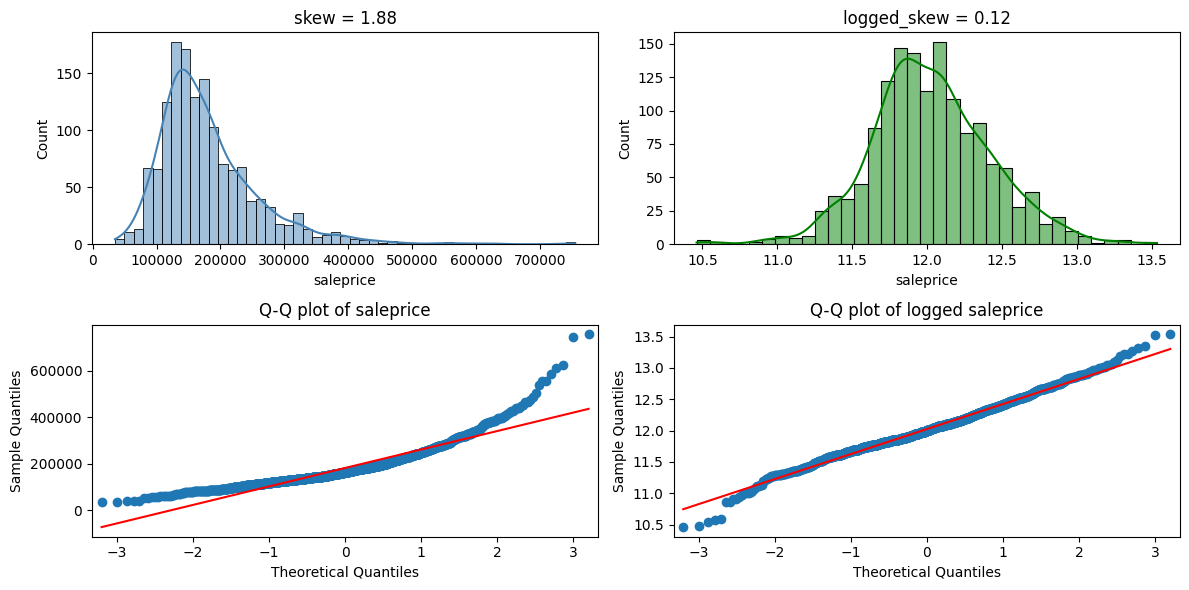

In [9]:
target = df['saleprice']
fig,axes = plt.subplots(2,2,figsize=(12,6))

sns.histplot(target,kde=True,ax=axes[0,0],color='steelblue')
axes[0,0].set_title(f'skew = {target.skew().round(2)}')

logged_target = np.log1p(target)
sns.histplot(logged_target,kde=True,ax=axes[0,1],color='green')
axes[0,1].set_title(f'logged_skew = {logged_target.skew().round(2)}')

sm.qqplot(target,line='s',ax=axes[1,0])
axes[1,0].set_title('Q-Q plot of saleprice')

sm.qqplot(logged_target,line='s',ax=axes[1,1])
axes[1,1].set_title('Q-Q plot of logged saleprice')

plt.tight_layout()
plt.show()


**Interpretation**

**From the plot above, we can observe followings:**

. Target variable is right skewed, having the skewness of 1.88

. After applying the logarithm , the skewness is reduced to 0.12

**DECISION** --> Must apply log1p() to saleprice for better model training


**6. Univariate analysis of features**


**6.1 Analysis of Continuous features**

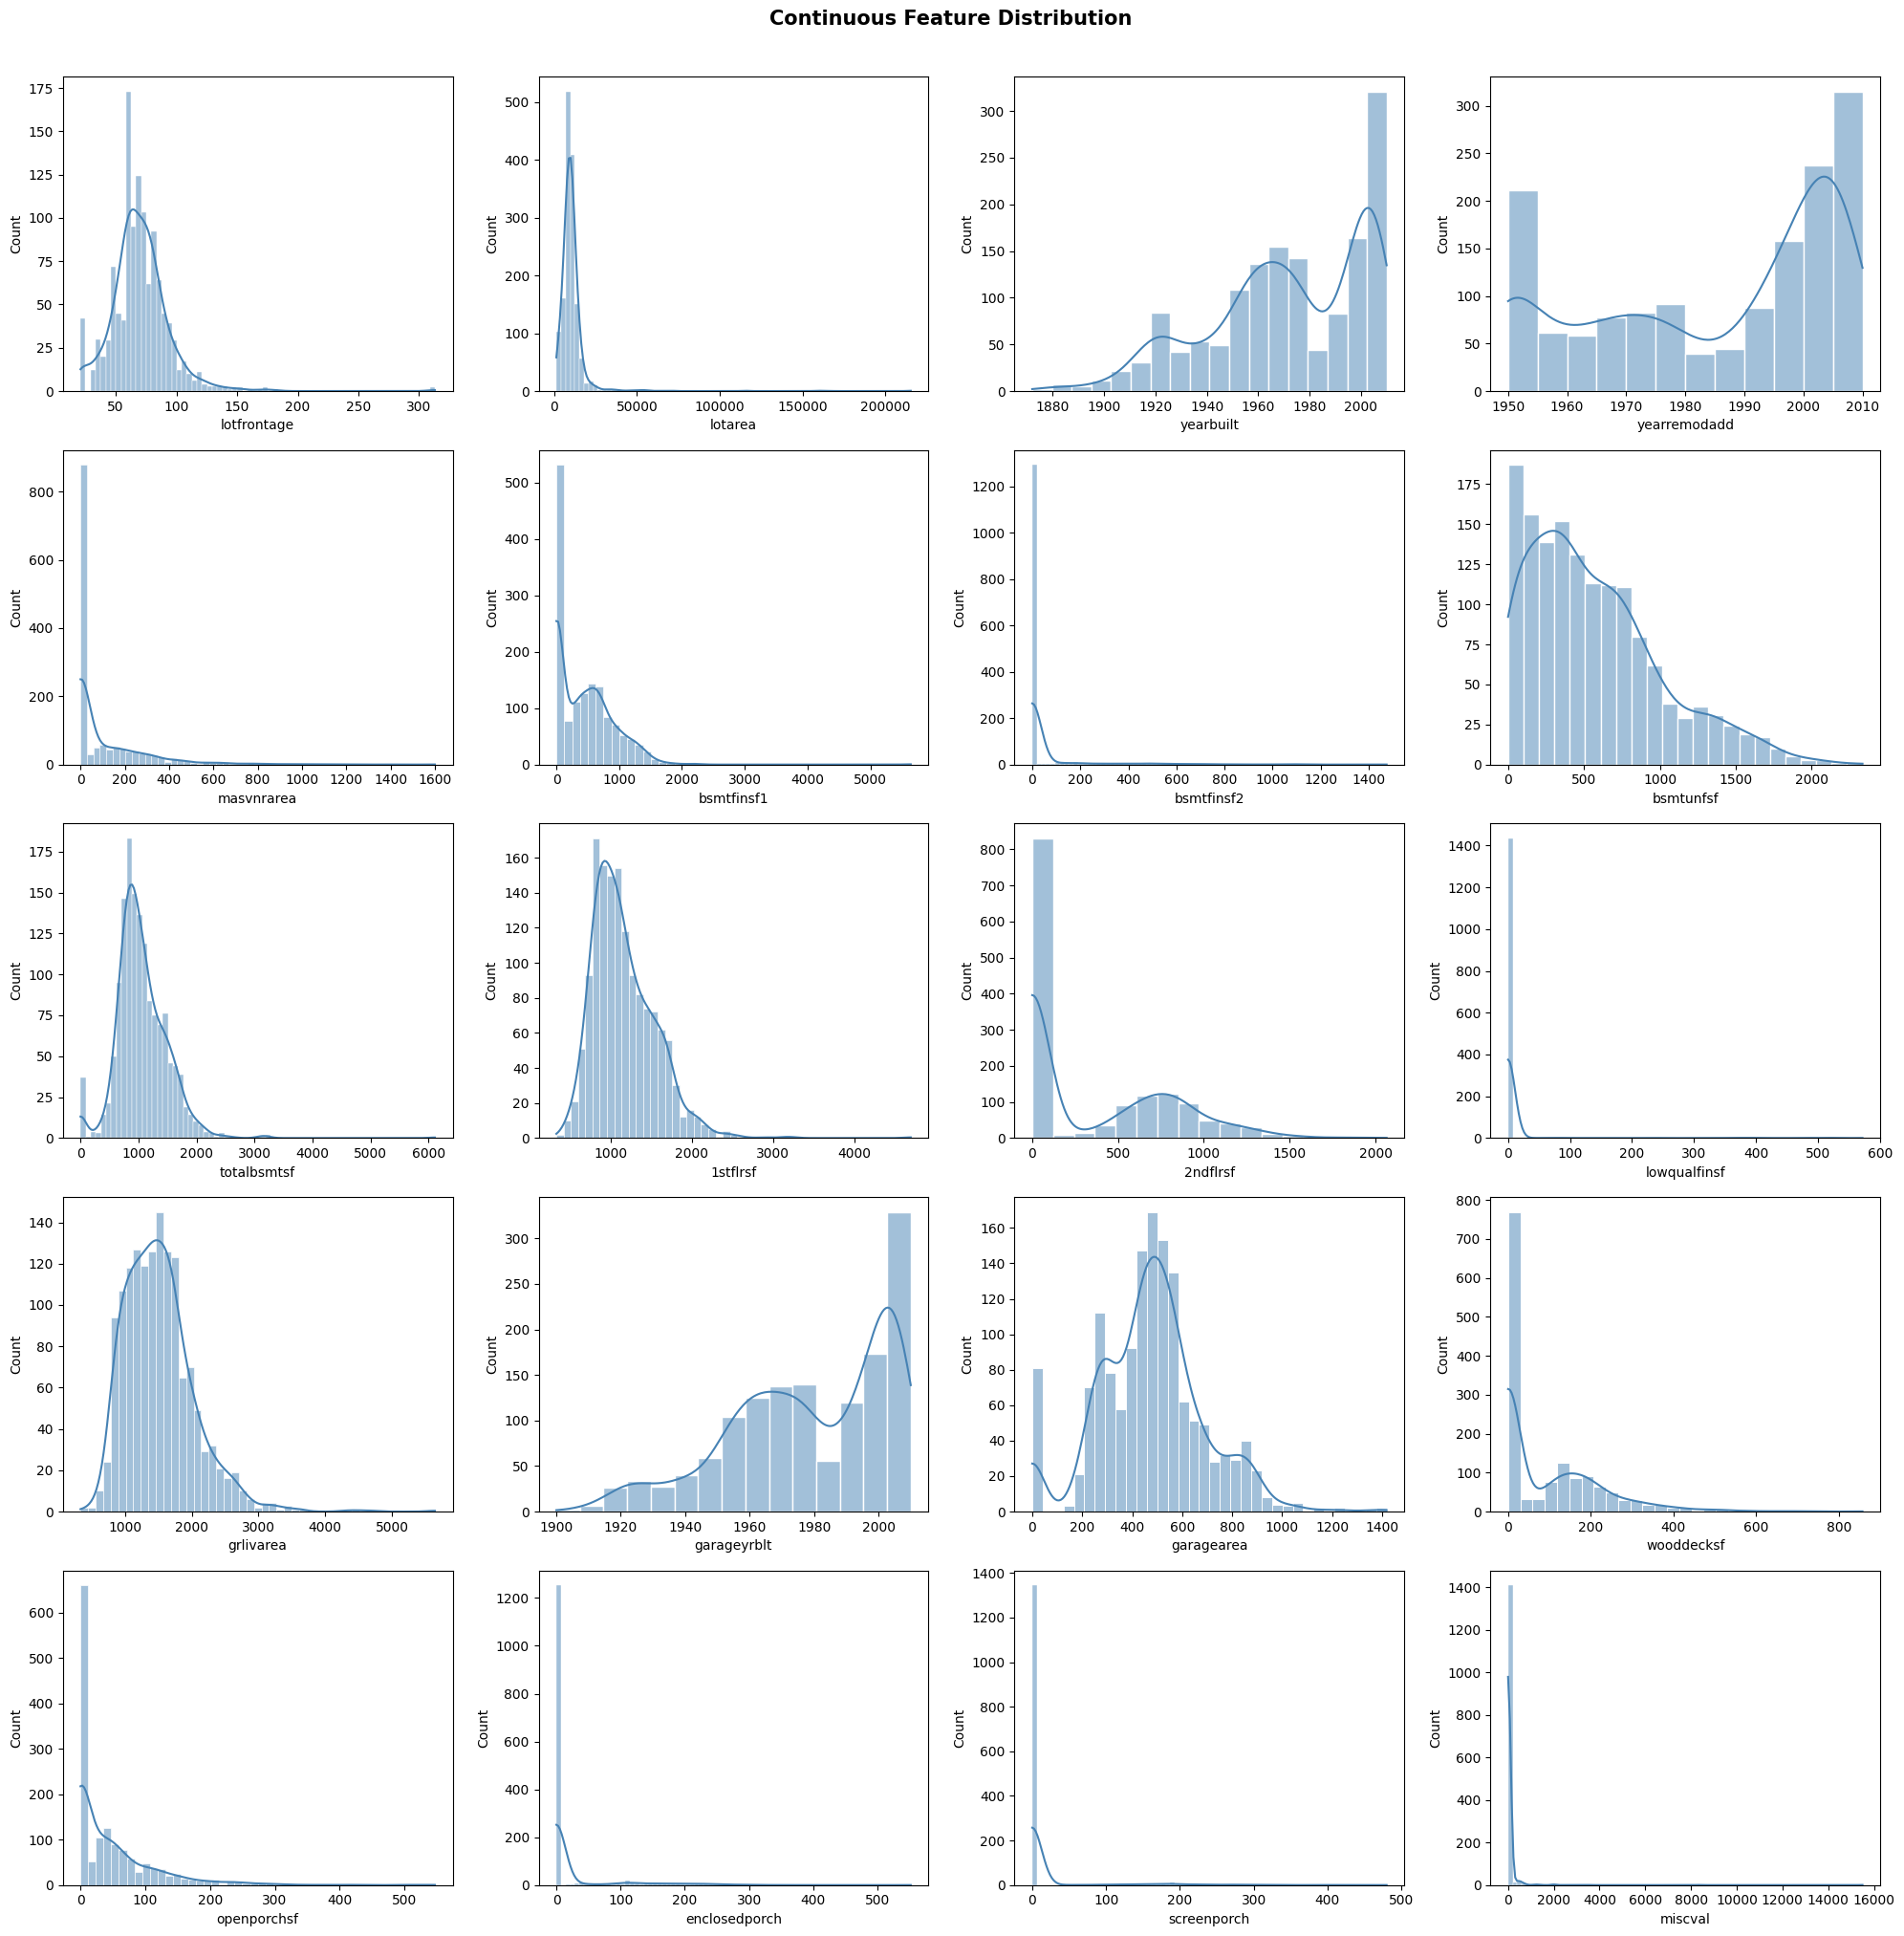

In [10]:
n_cols = 4
n_rows = int(np.ceil(len(continuous) / n_cols))
fig,axes = plt.subplots(n_rows,n_cols,figsize=(20,n_rows * 4))
axes = axes.flatten()
for i,feature in enumerate(continuous):
    sns.histplot(df_raw[feature],kde=True,ax=axes[i],color='steelblue', edgecolor='white')
    axes[i].set_xlabel(feature)
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Continuous Feature Distribution',fontsize='15',fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

**6.2 Analysis of Discrete Features**

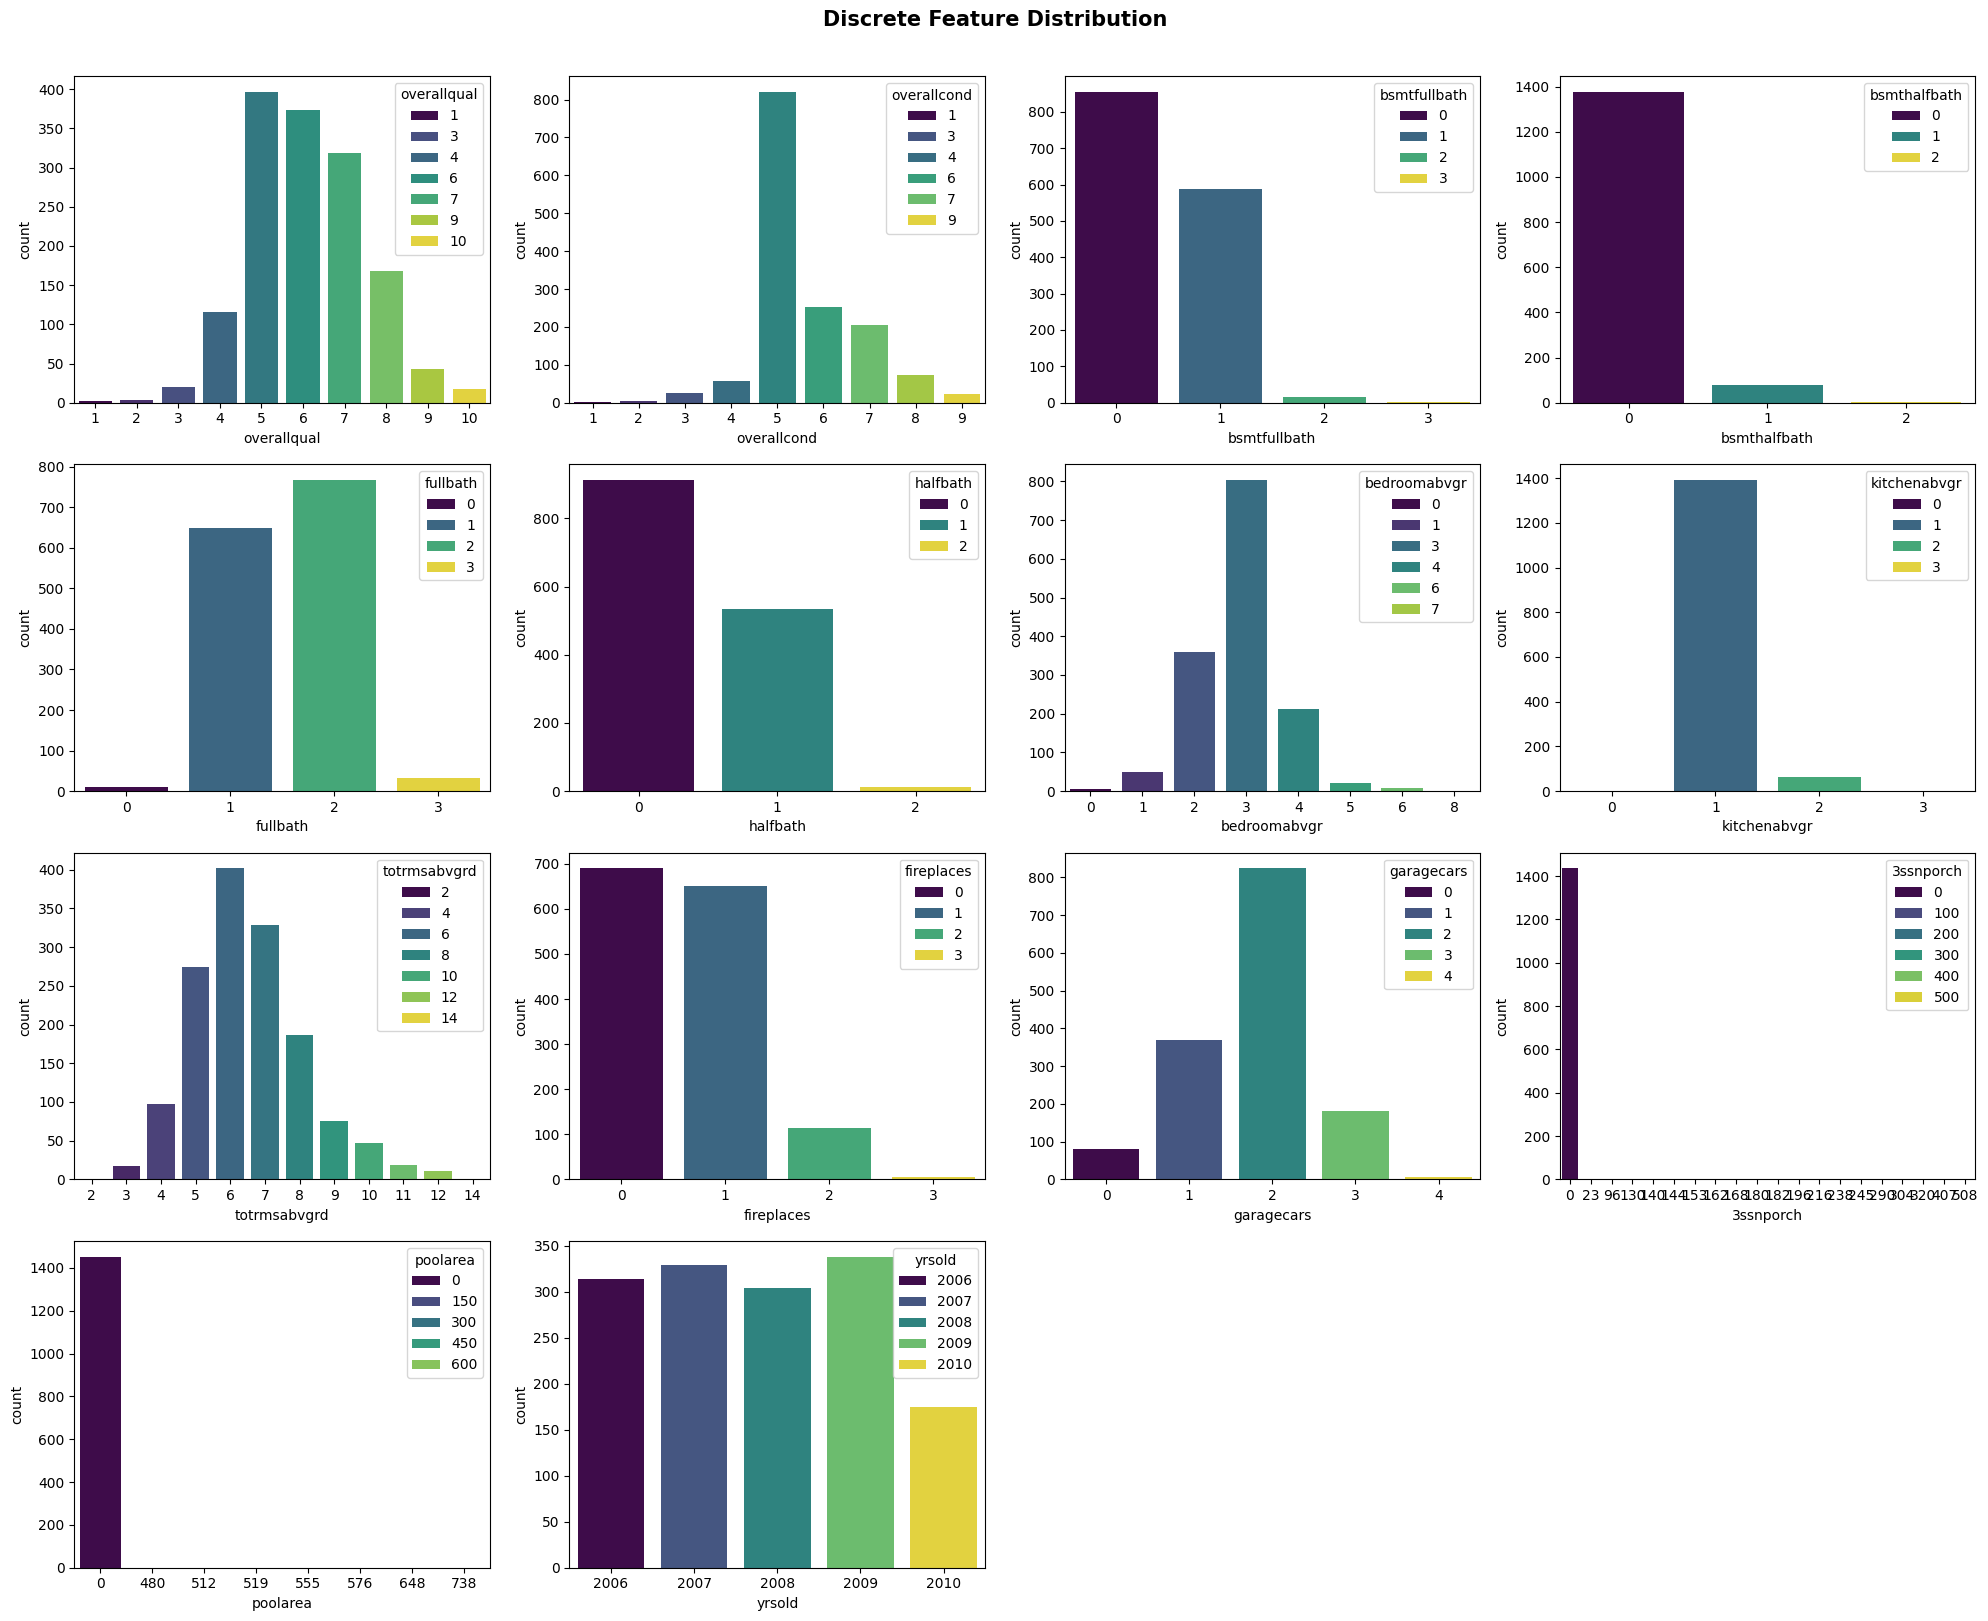

In [11]:
n_cols = 4
n_rows = int(np.ceil(len(discrete) / n_cols))
fig,axes = plt.subplots(n_rows,n_cols,figsize=(20,n_rows * 4))
axes = axes.flatten()
for i,feature in enumerate(discrete):
    order = sorted(df_raw[feature])
    sns.countplot(x=df_raw[feature],order = order,ax=axes[i],palette='viridis',hue=df_raw[feature])
    axes[i].set_xlabel(feature)
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Discrete Feature Distribution',fontsize='15',fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

**6.3 Checking the skewness of the numerical features**

In [12]:
skewness_table = pd.DataFrame({
    'skewness':df_raw[numerical].skew(),        #skewness value of each numerical features
    'missing':df_raw[numerical].isnull().sum()  #total number of null values in each numerical features
}).sort_values('skewness',ascending=False)
skewness_table['apply logarithm'] = skewness_table['skewness'] > 0.75
skewness_table['apply square'] = skewness_table['skewness'] < -0.75
def highlight_skewed(row):
    if row['apply logarithm'] == True:
        return ['background-color: #fff3cd; color: black'] * len(row)  # yellow highlight
    return [''] * len(row)
display(skewness_table.style.apply(highlight_skewed, axis=1))


,skewness,missing,apply logarithm,apply square
miscval,24.476794,0,True,False
poolarea,14.828374,0,True,False
lotarea,12.207688,0,True,False
3ssnporch,10.304342,0,True,False
lowqualfinsf,9.011341,0,True,False
kitchenabvgr,4.488397,0,True,False
bsmtfinsf2,4.255261,0,True,False
screenporch,4.122214,0,True,False
bsmthalfbath,4.103403,0,True,False
enclosedporch,3.089872,0,True,False


**Interpretation**

**From the plot above, we can observe followings:**

. Numerical varaibles such as [MiscVal
PoolArea
LotArea
3SsnPorch
LowQualFinSF
KitchenAbvGr
BsmtFinSF2
ScreenPorch
BsmtHalfBath
EnclosedPorch
MasVnrArea
OpenPorchSF
LotFrontage
BsmtFinSF1
WoodDeckSF
TotalBsmtSF
1stFlrSF
GrLivArea
BsmtUnfSF
2ndFlrSF]   have higher skewness value that can affect the model training and prevent the model from predicting the saleprice of house accurately.

.So, its better to apply log1p() to reduce the skewness of these numerical variables.


**DECISION** --> Must apply log1p() to these selected variables for better model training


**6.4 Plot of outliers**

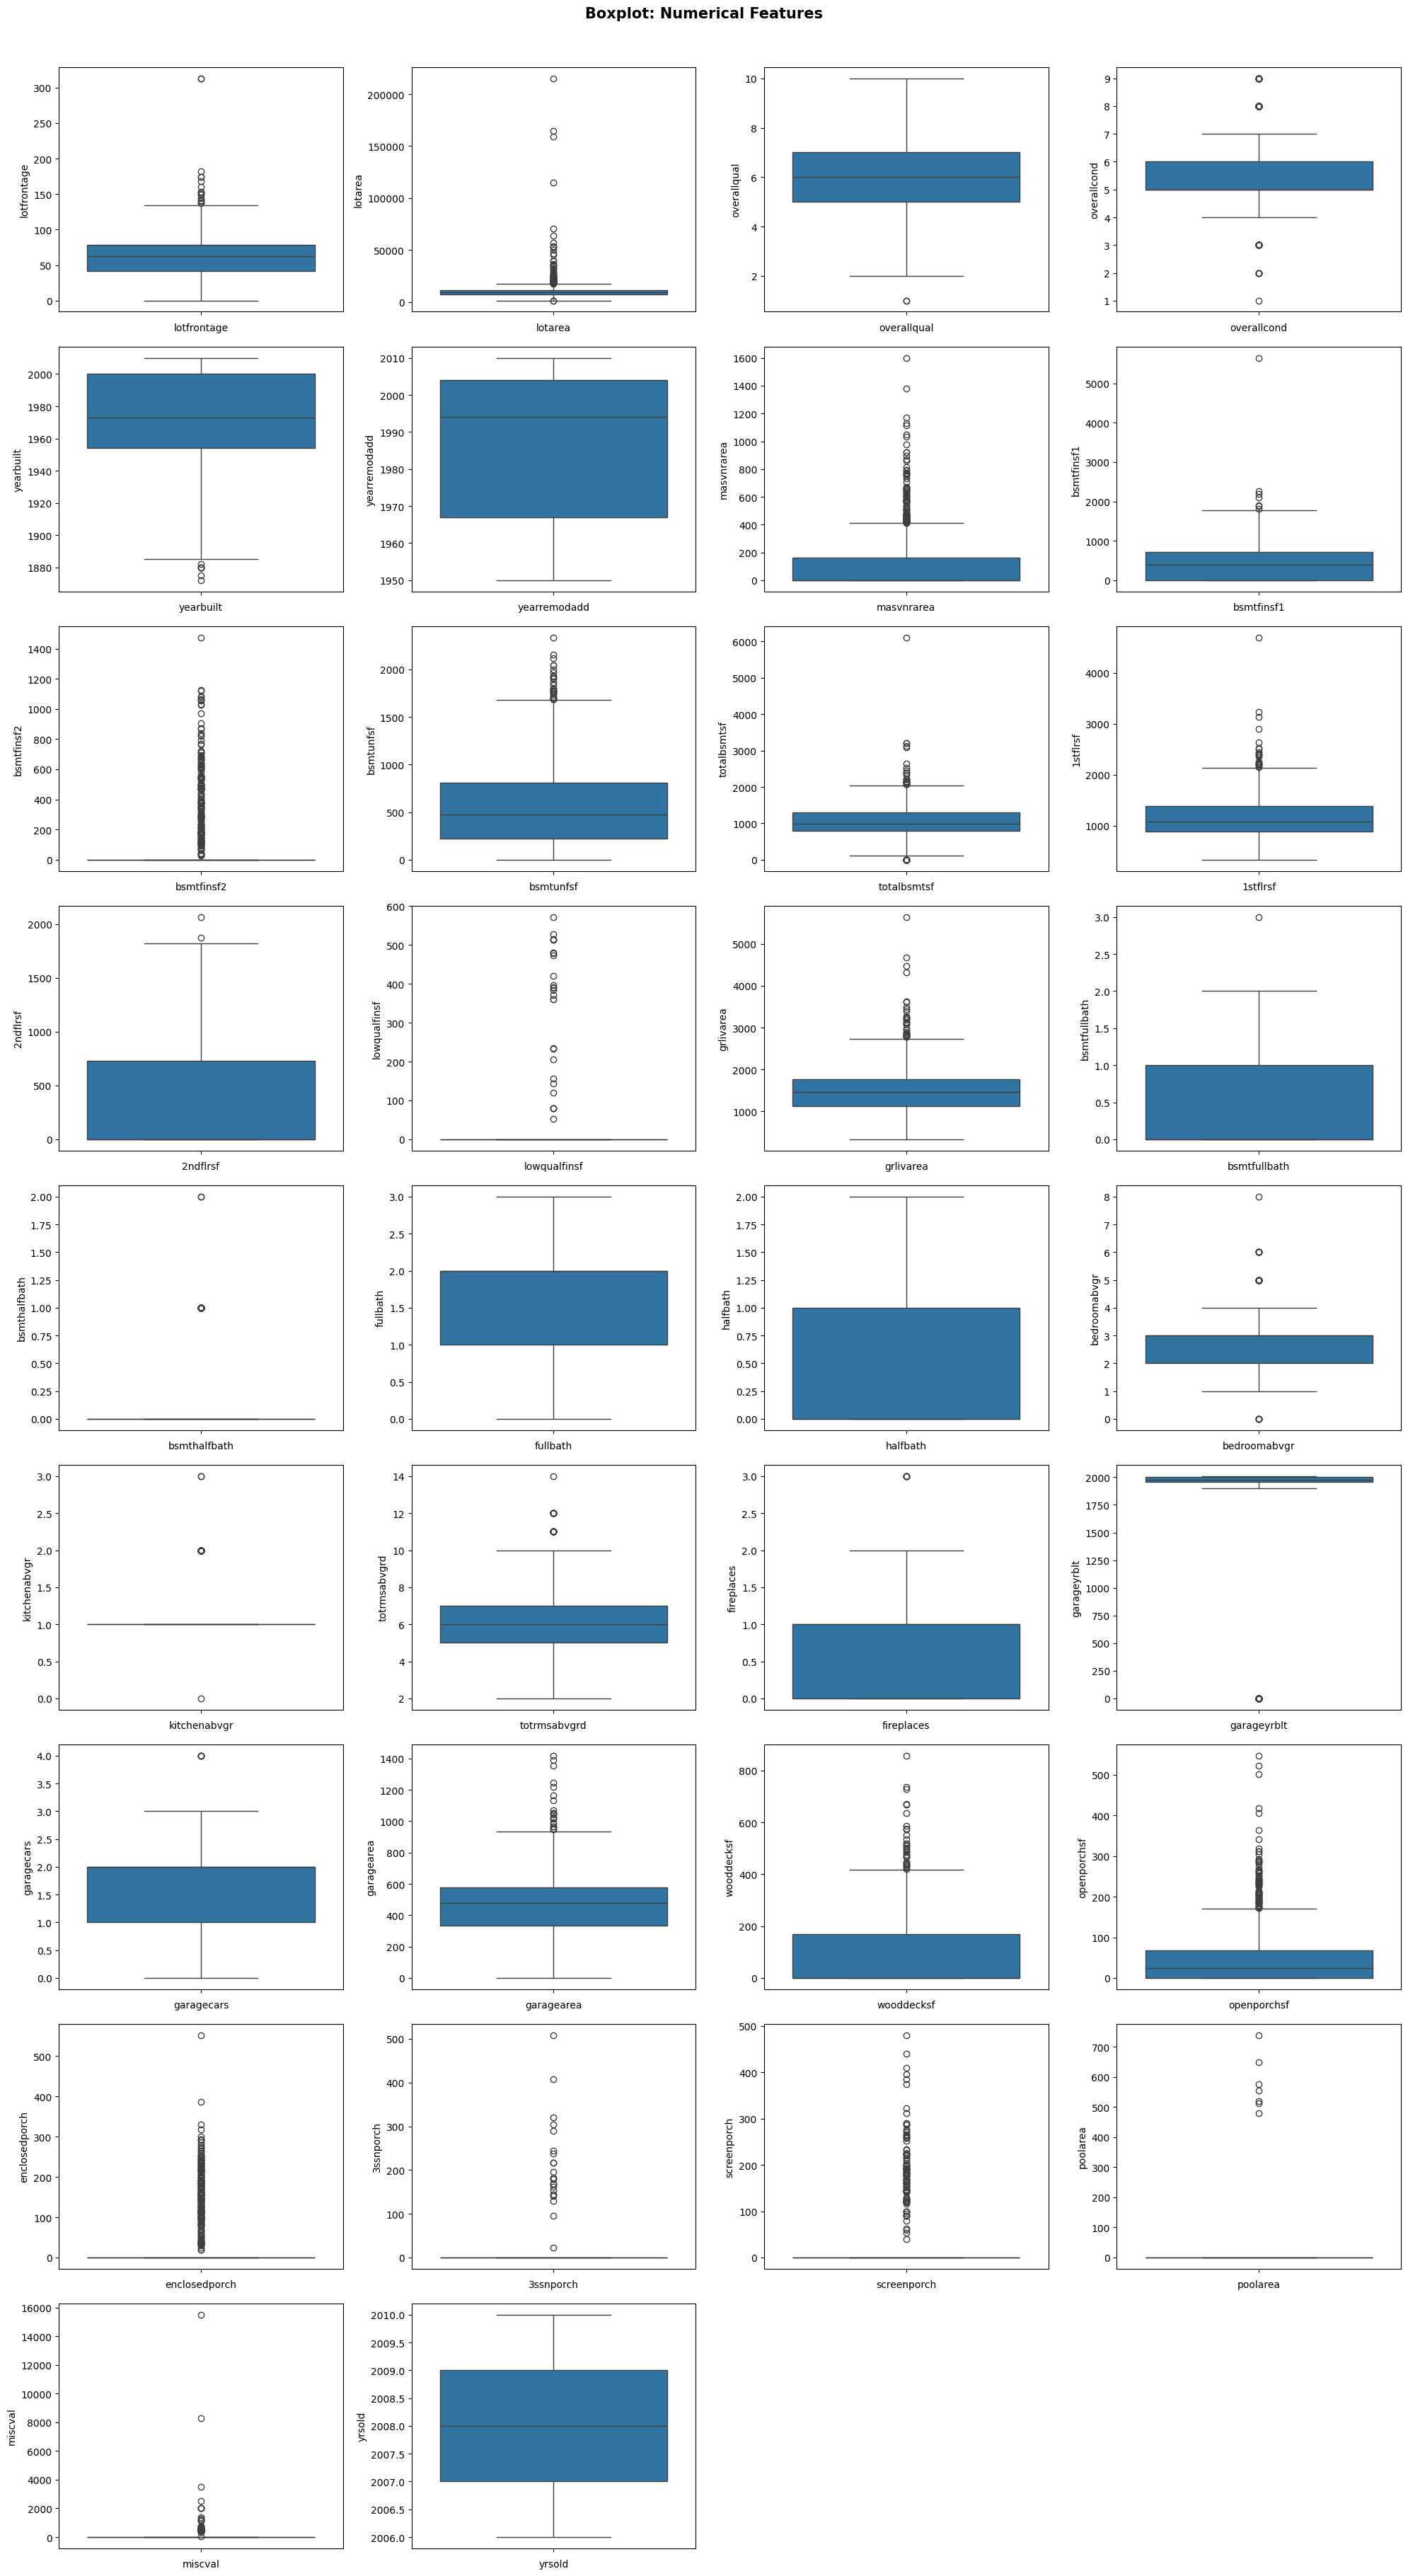

In [13]:
n_cols = 4
n_rows = int(np.ceil(len(numerical) / n_cols))
fig,axes = plt.subplots(n_rows,n_cols,figsize=(20,n_rows * 4))
axes = axes.flatten()
for i,feature in enumerate(numerical):
    sns.boxplot(y=df_raw[feature].fillna(0),ax=axes[i])
    axes[i].set_xlabel(feature)
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Boxplot: Numerical Features',fontsize='15',fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

**6.5 Analysis of Categorical Features**

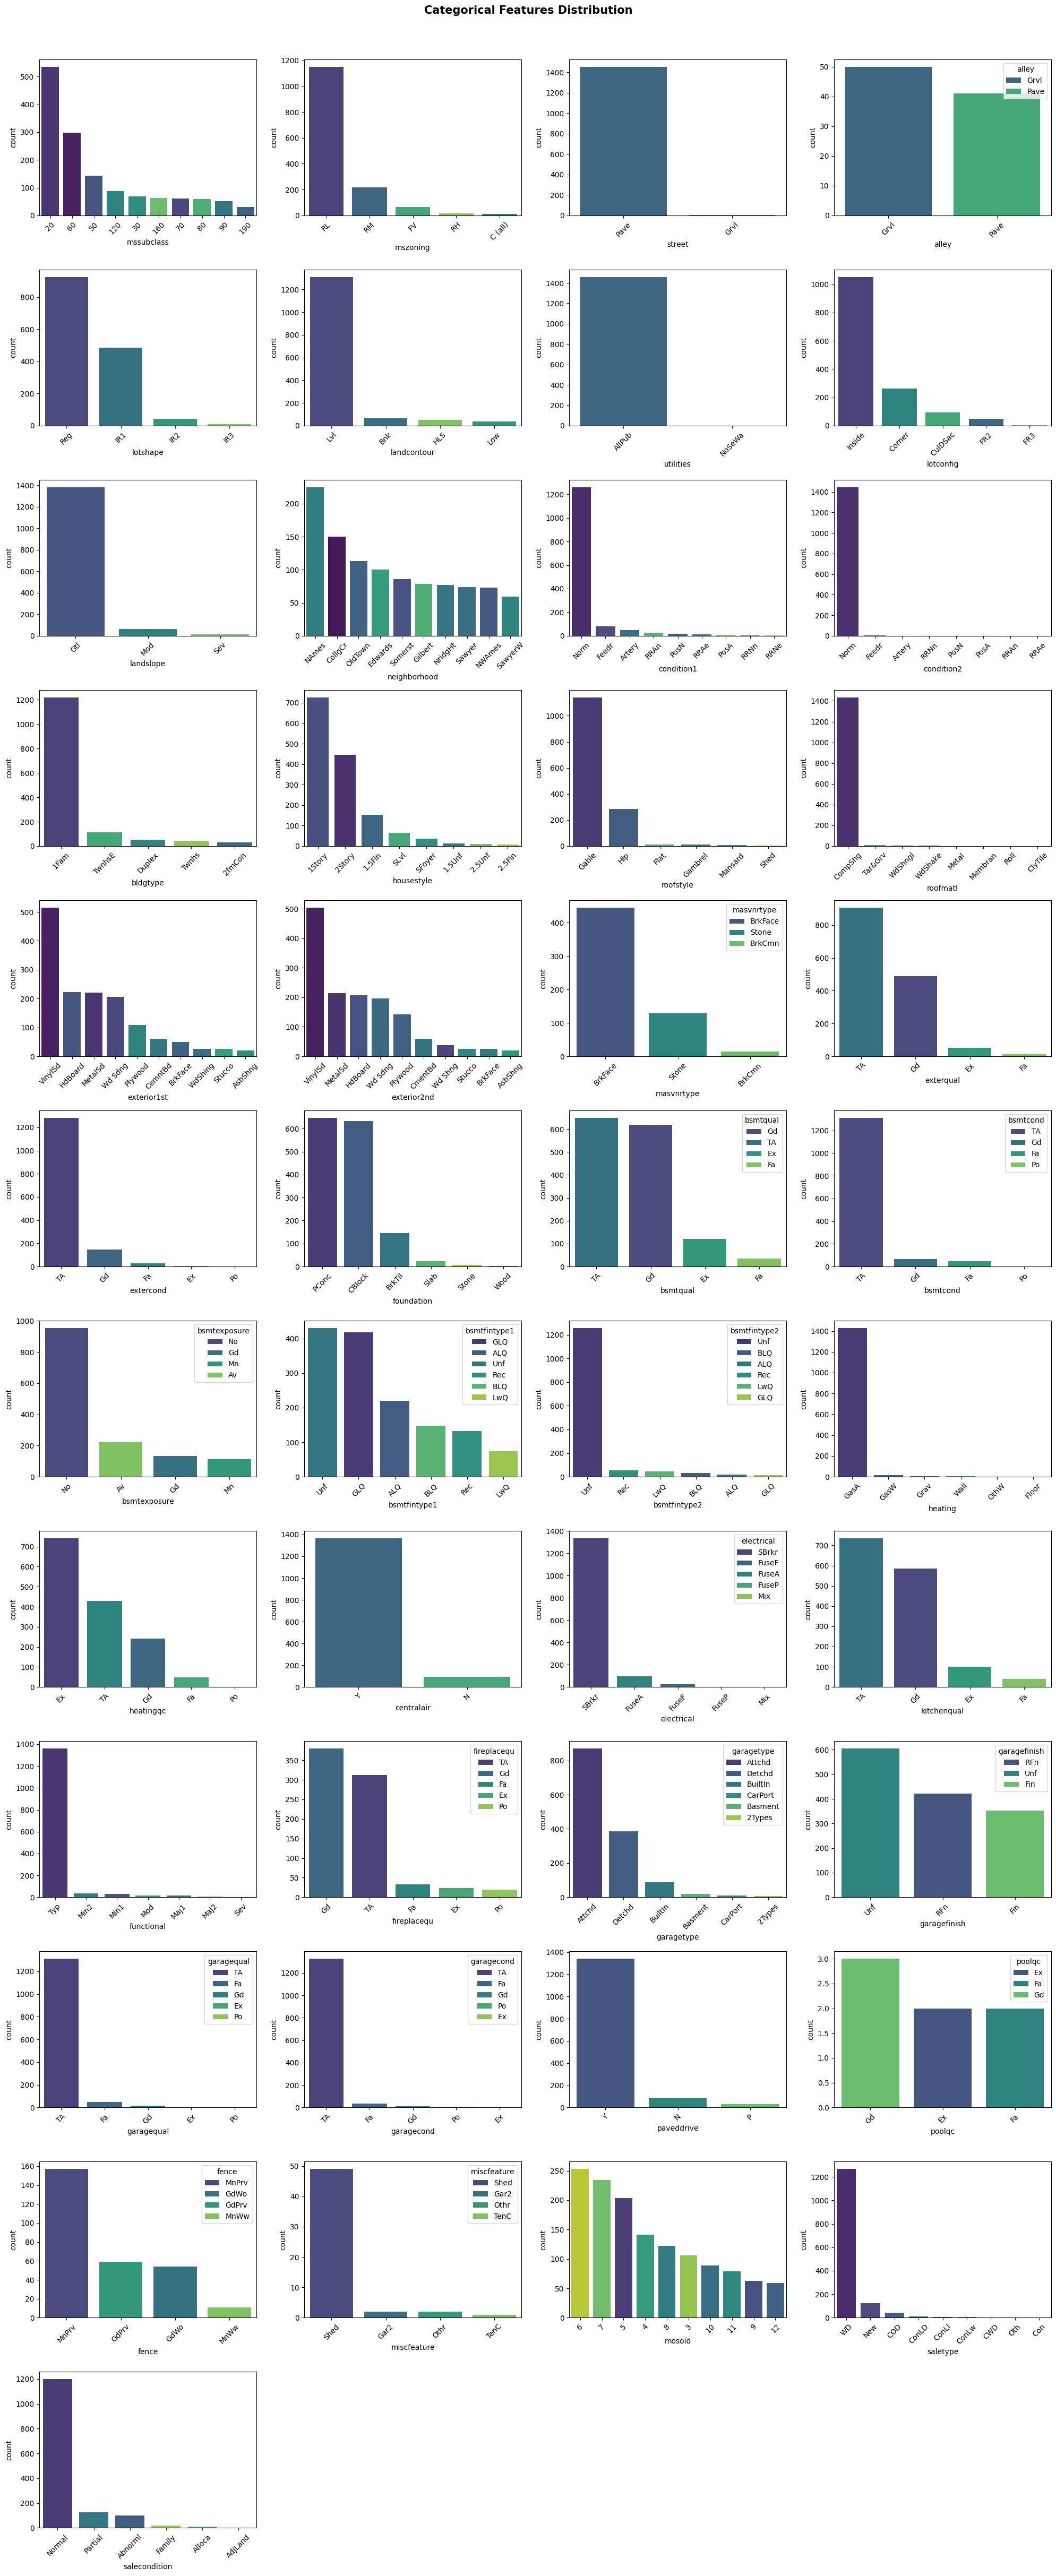

In [14]:
n_cols = 4
n_rows = int(np.ceil(len(categorical) / n_cols))
fig,axes = plt.subplots(n_rows,n_cols,figsize=(20,n_rows * 4))
axes = axes.flatten()
for i,feature in enumerate(categorical):
    order = df_raw[feature].value_counts().nlargest(10).index  #only picking up the top 10 frequently occuring categories from each feature or column
    sns.countplot(x=df_raw[feature],order = order ,ax=axes[i],palette='viridis',hue=df_raw[feature])
    axes[i].set_xlabel(feature)
    axes[i].tick_params(axis='x',rotation=45)
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Categorical Features Distribution',fontsize='15',fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

**6.6 Rare categories in categorical features**

In [15]:
def rare_categories(df,data_type):
    rare_cat_dict = {}
    for feature in data_type:
        frequency = df[feature].value_counts(normalize=True)  #couting the frequency of every category in this current feature
        rare_categories = frequency[frequency<0.01].index.tolist()   #converting into result of rare categories into list
        if rare_categories:
            rare_cat_dict[feature] = rare_categories
    return rare_cat_dict       

print('---Categories that appear rarely in the training dataset, for every categorical features---\n')
display(rare_categories(df_raw,categorical))
print('')
print('DECISION -->Either group them into "Other section" or use target encoding')

        

---Categories that appear rarely in the training dataset, for every categorical features---



{'mssubclass': ['45', '180', '40'],
 'mszoning': ['C (all)'],
 'street': ['Grvl'],
 'lotshape': ['IR3'],
 'utilities': ['NoSeWa'],
 'lotconfig': ['FR3'],
 'landslope': ['Sev'],
 'neighborhood': ['Veenker', 'NPkVill', 'Blueste'],
 'condition1': ['RRAe', 'PosA', 'RRNn', 'RRNe'],
 'condition2': ['Feedr', 'Artery', 'RRNn', 'PosN', 'PosA', 'RRAn', 'RRAe'],
 'housestyle': ['1.5Unf', '2.5Unf', '2.5Fin'],
 'roofstyle': ['Flat', 'Gambrel', 'Mansard', 'Shed'],
 'roofmatl': ['Tar&Grv',
  'WdShngl',
  'WdShake',
  'Metal',
  'Membran',
  'Roll',
  'ClyTile'],
 'exterior1st': ['BrkComm', 'Stone', 'AsphShn', 'ImStucc', 'CBlock'],
 'exterior2nd': ['ImStucc', 'Brk Cmn', 'Stone', 'AsphShn', 'Other', 'CBlock'],
 'exterqual': ['Fa'],
 'extercond': ['Ex', 'Po'],
 'foundation': ['Stone', 'Wood'],
 'bsmtcond': ['Po'],
 'bsmtfintype2': ['GLQ'],
 'heating': ['Grav', 'Wall', 'OthW', 'Floor'],
 'heatingqc': ['Po'],
 'electrical': ['FuseP', 'Mix'],
 'functional': ['Maj1', 'Maj2', 'Sev'],
 'garagetype': ['CarPort


DECISION -->Either group them into "Other section" or use target encoding


**7. Bivariate Analysis**

**7.1 Bivariate Analysis: Saleprice vs continuous numerical data**

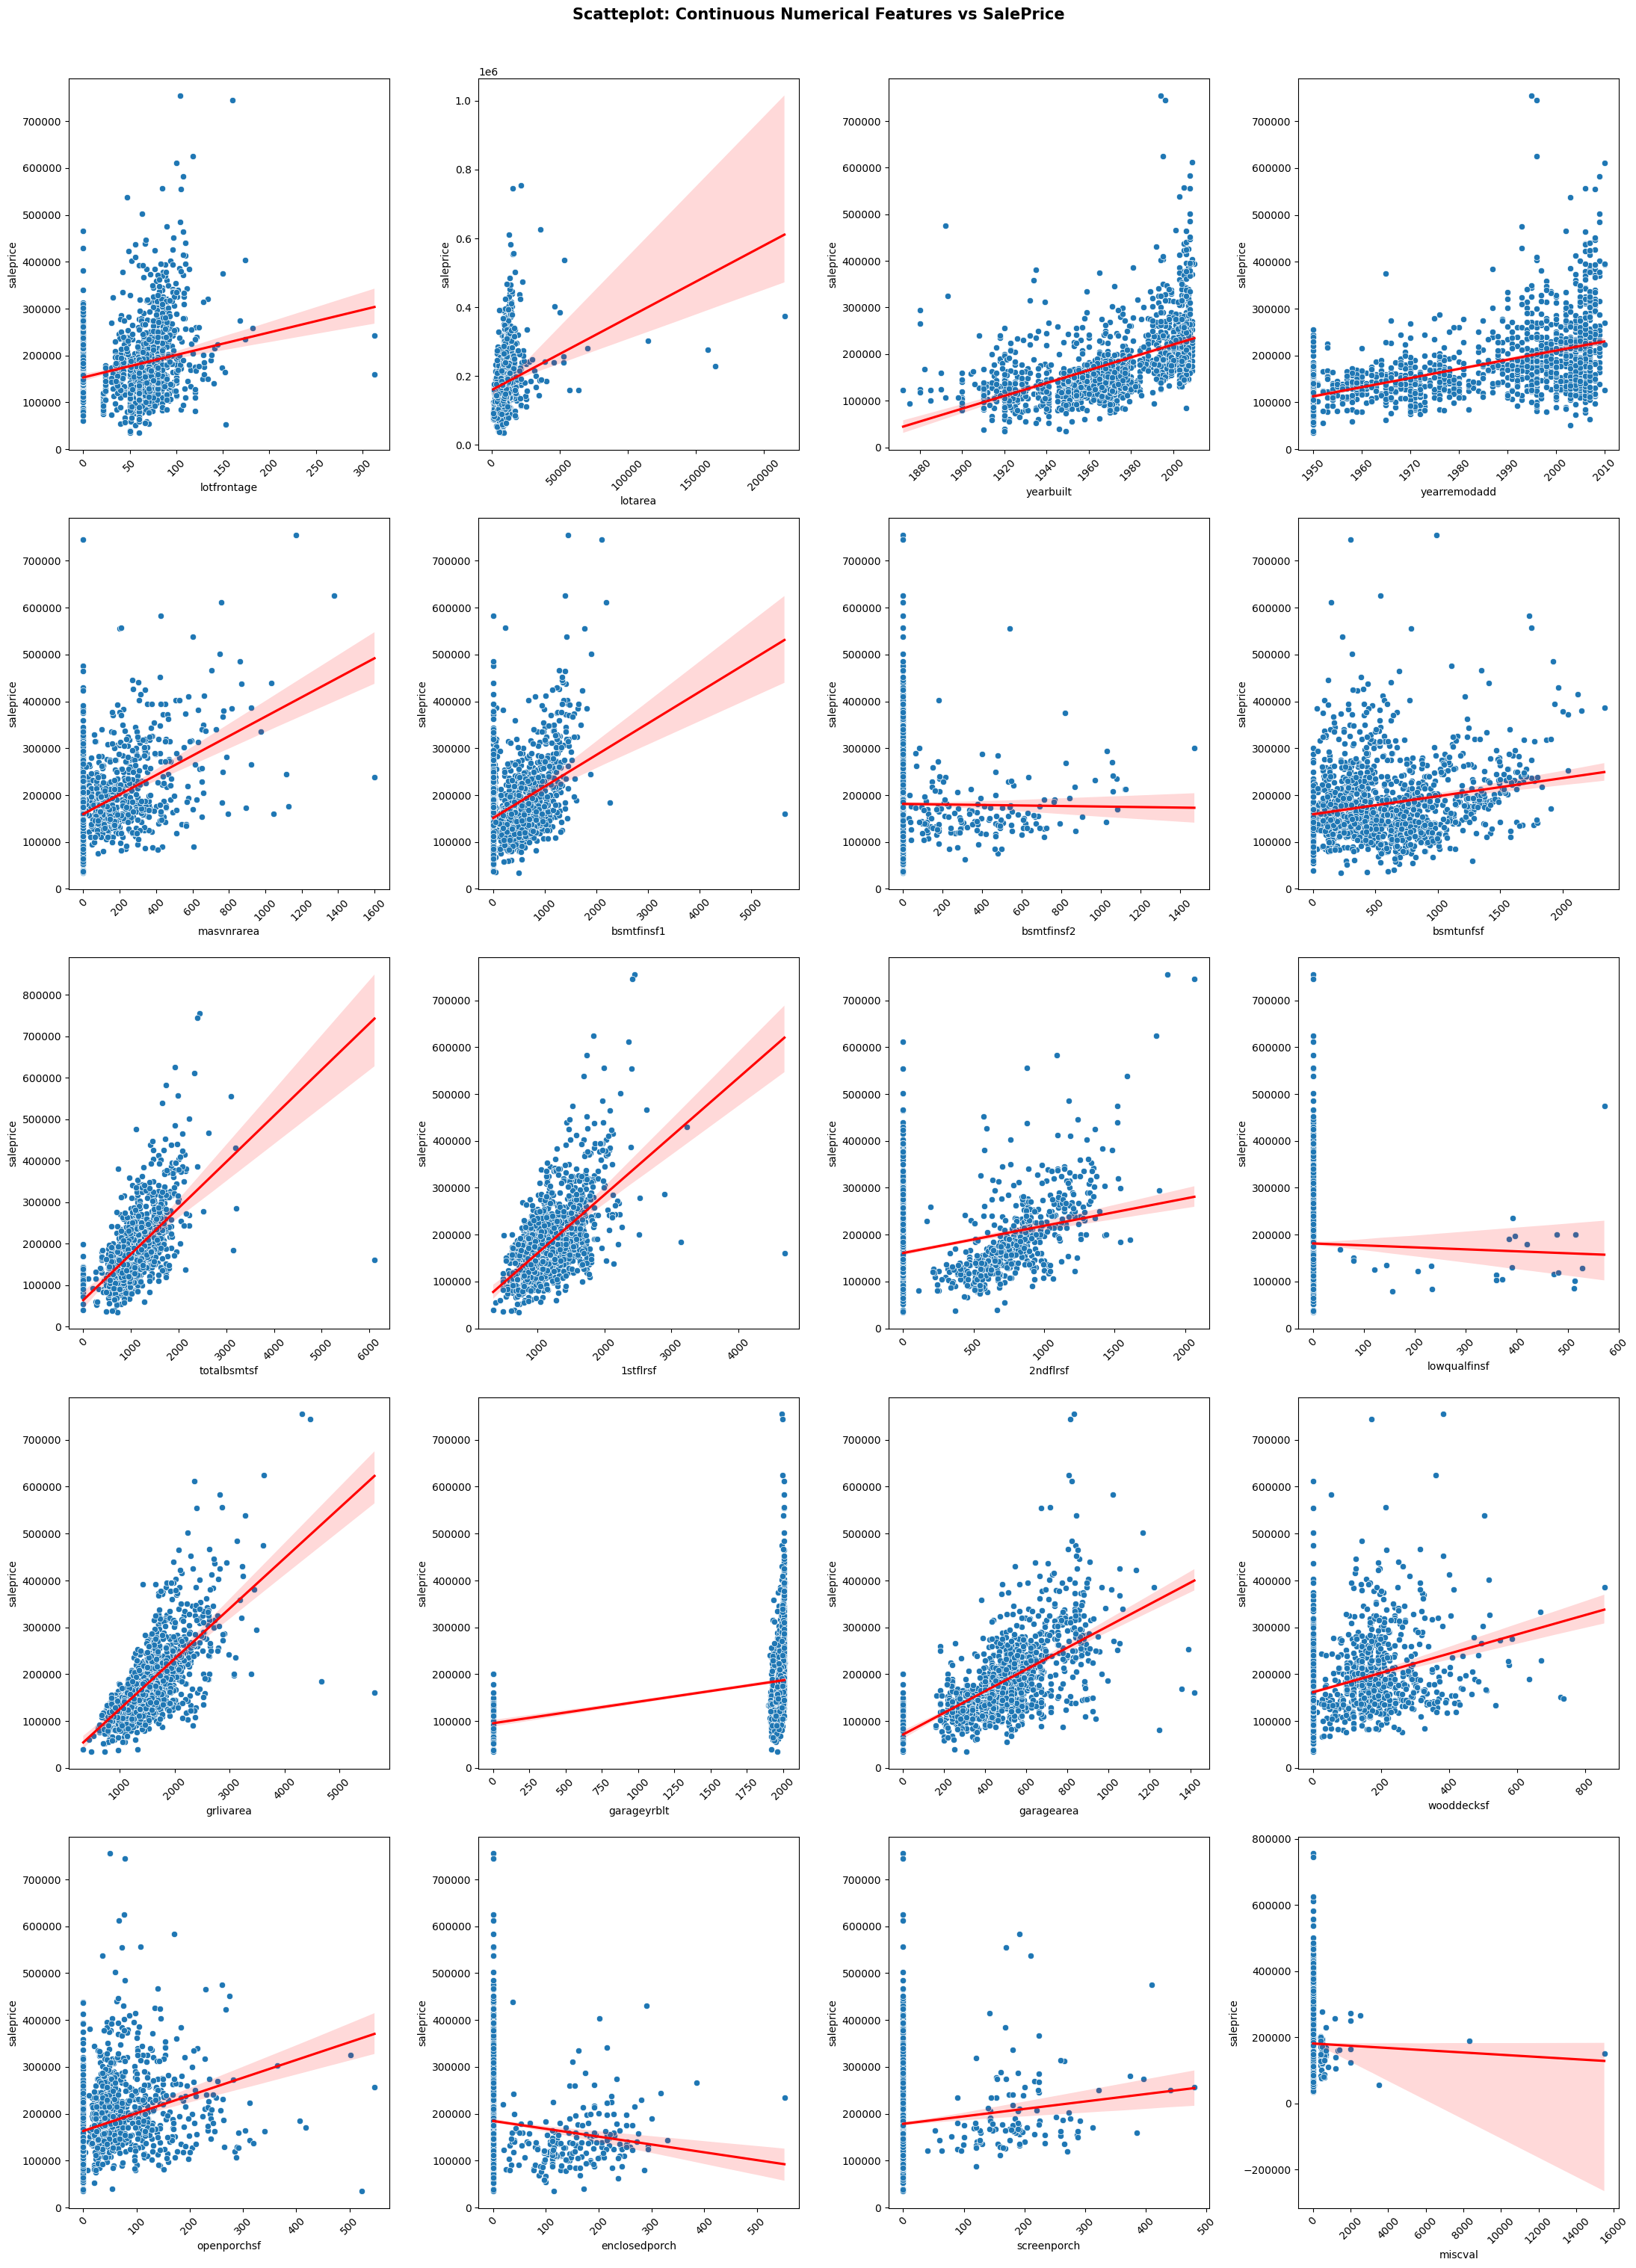

In [16]:
n_cols = 4
n_rows = int(np.ceil(len(continuous) / n_cols))
fig,axes = plt.subplots(n_rows,n_cols,figsize=(22,n_rows * 6))
axes = axes.flatten()
for i,feature in enumerate(continuous):
    sns.scatterplot(x=df_raw[feature].fillna(0),y=df_raw['saleprice'],ax=axes[i])
    sns.regplot(x=df_raw[feature].fillna(0),y=df_raw['saleprice'],scatter=False,color='red',ax=axes[i])
    axes[i].set_xlabel(feature)
    axes[i].tick_params(axis='x',rotation=45)
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Scatteplot: Continuous Numerical Features vs SalePrice',fontsize='15',fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

**7.2 Bivariate Analysis: Saleprice vs Discrete Numerical Data**

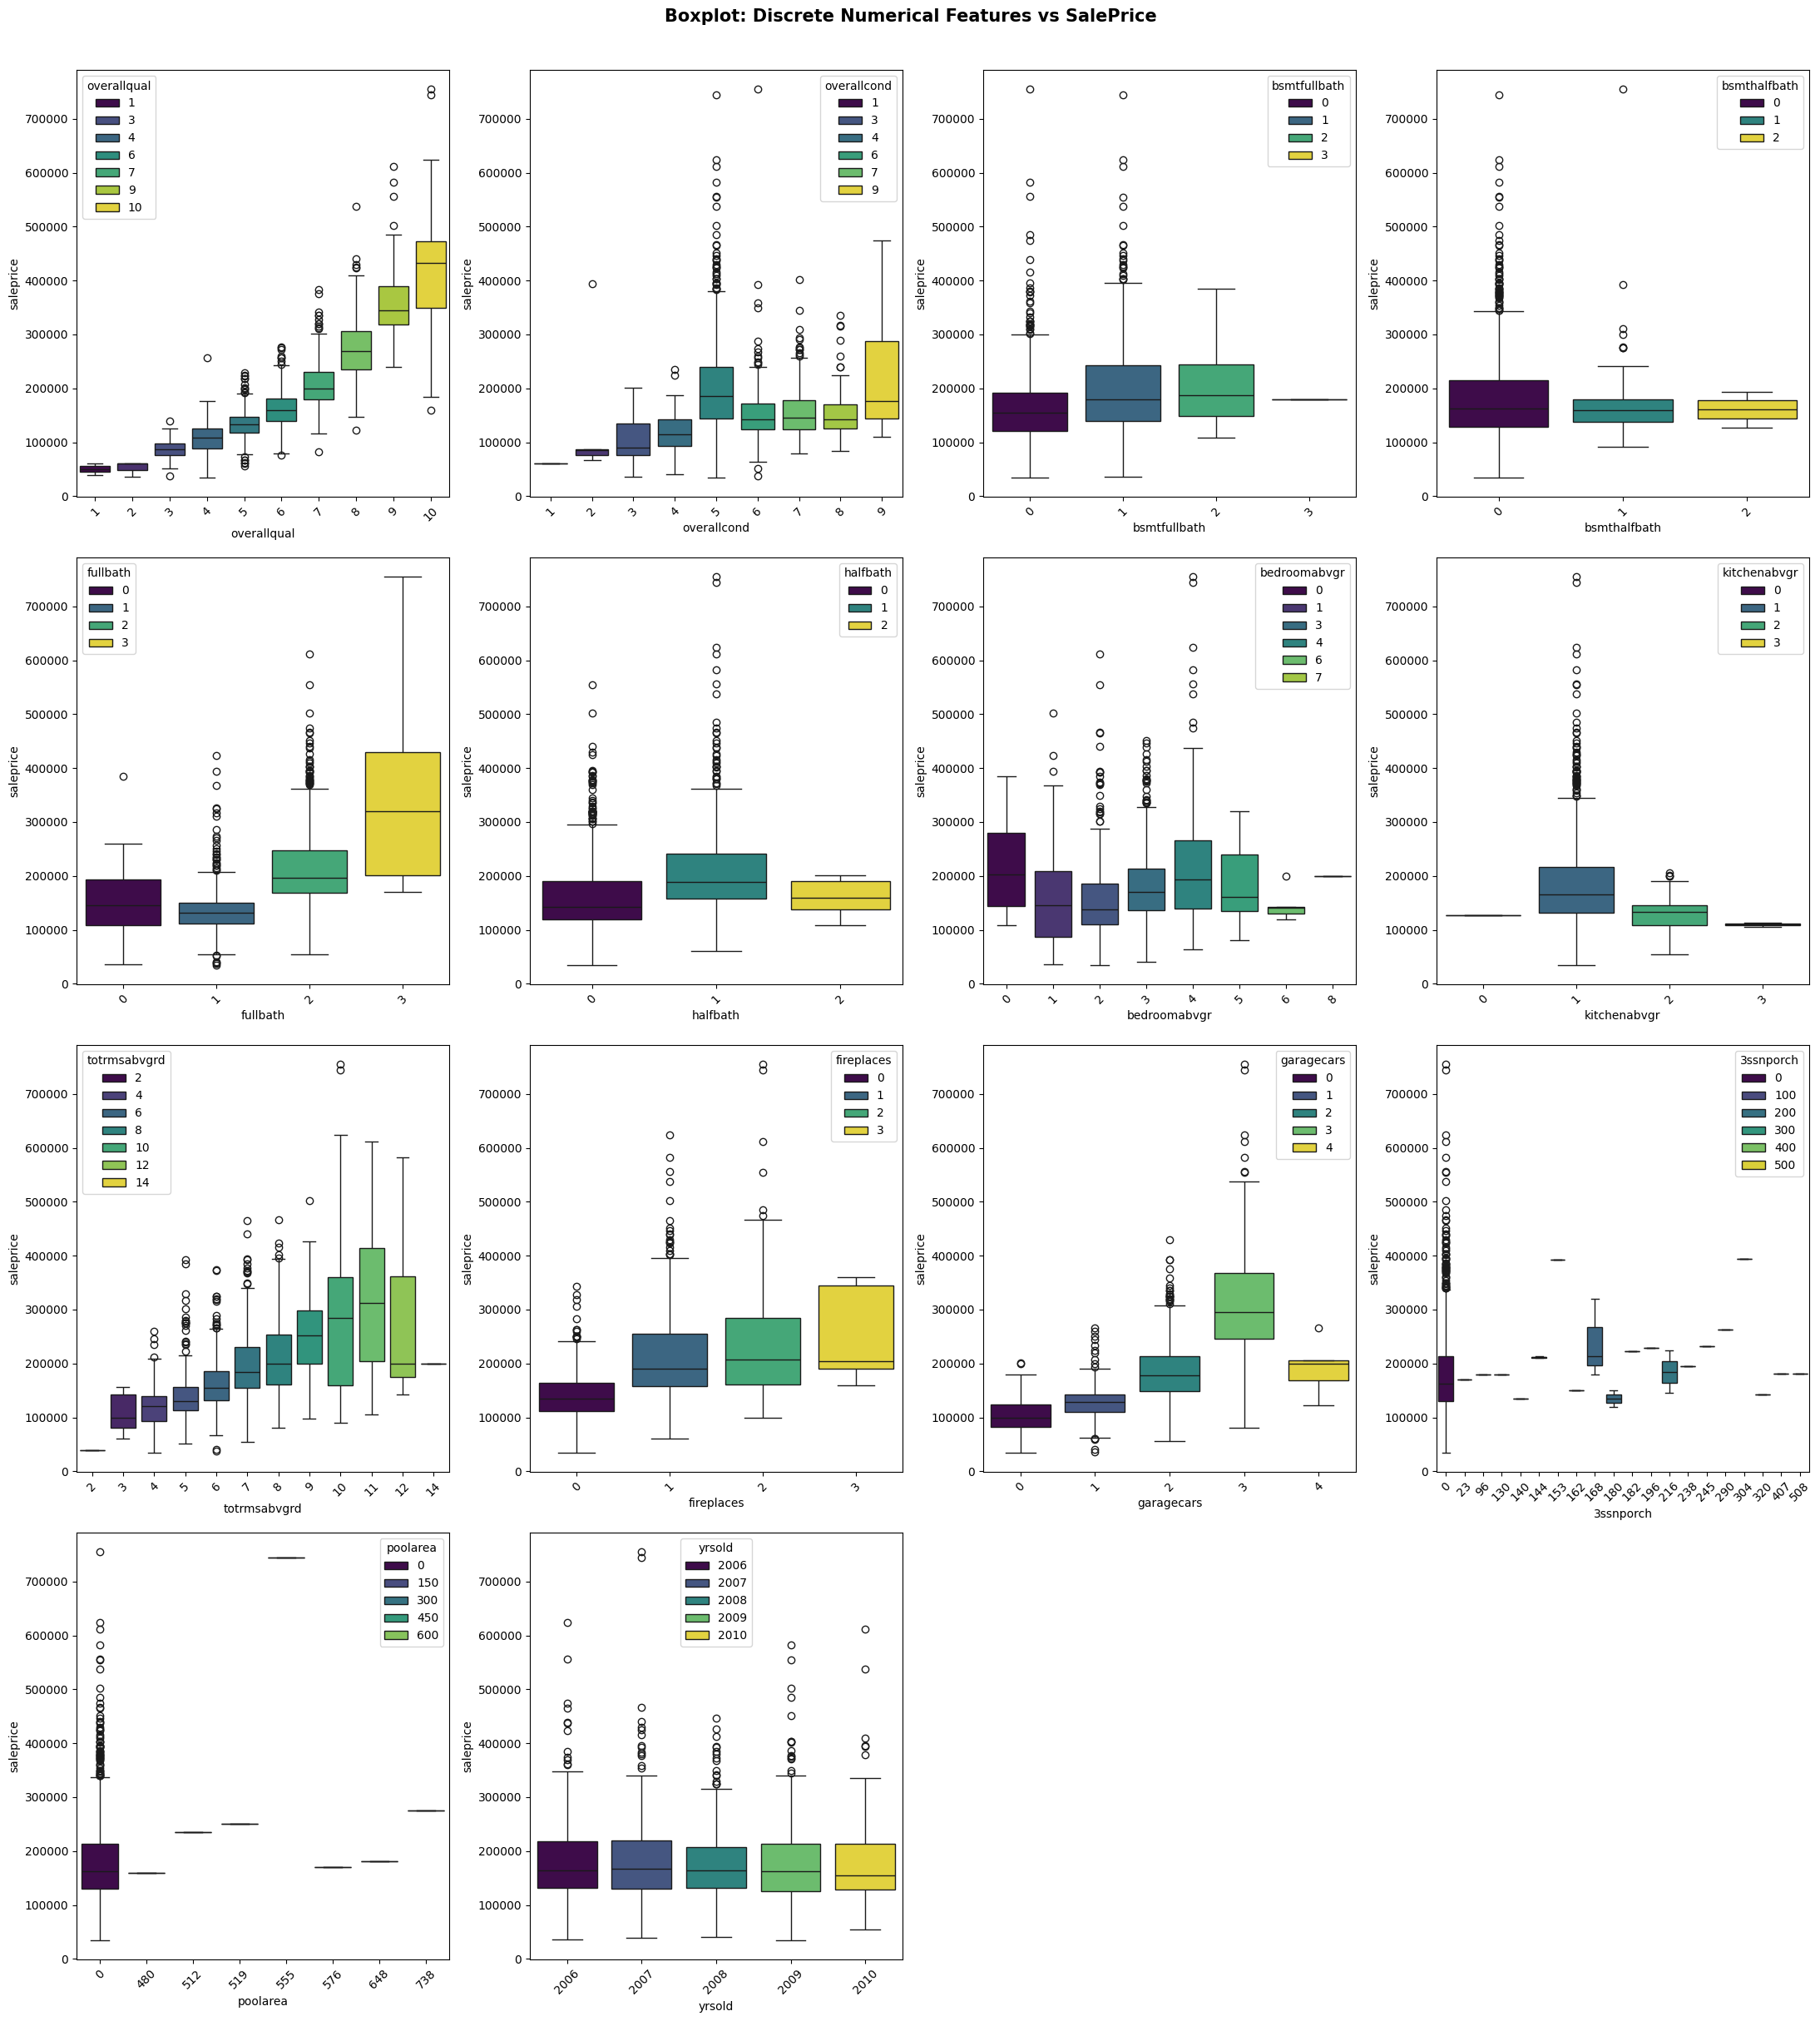

In [20]:
n_cols = 4
n_rows = int(np.ceil(len(discrete) / n_cols))
fig,axes = plt.subplots(n_rows,n_cols,figsize=(22,n_rows * 6))
axes = axes.flatten()
for i,feature in enumerate(discrete):
    order = sorted(df_raw[feature].fillna(0))
    sns.boxplot(x=df_raw[feature].fillna(0),y=df_raw['saleprice'],ax=axes[i],palette='viridis',hue=df_raw[feature])
    axes[i].set_xlabel(feature)
    axes[i].tick_params(axis='x',rotation=45) 
for j in range(i+1,len(axes)):
    axes[j].set_visible(False)  #removing the unused axes

fig.suptitle('Boxplot: Discrete Numerical Features vs SalePrice',fontsize='15',fontweight='bold',y=1.01)
plt.tight_layout()
plt.show()

**7.3 Co-relation Bar chart and Heatmap**


In [22]:
corr = df[numerical + ['saleprice']].corr()['saleprice'].drop('saleprice')  #finding the correlation of all the numeric features with the target variable
corr_sorted = corr.sort_values(ascending=False)
corr_sorted

overallqual      0.790982
grlivarea        0.708624
garagecars       0.640409
garagearea       0.623431
totalbsmtsf      0.613581
1stflrsf         0.605852
fullbath         0.560664
totrmsabvgrd     0.533723
yearbuilt        0.522897
yearremodadd     0.507101
garageyrblt      0.486362
masvnrarea       0.477493
fireplaces       0.466929
bsmtfinsf1       0.386420
lotfrontage      0.351799
wooddecksf       0.324413
2ndflrsf         0.319334
openporchsf      0.315856
halfbath         0.284108
lotarea          0.263843
bsmtfullbath     0.227122
bsmtunfsf        0.214479
bedroomabvgr     0.168213
screenporch      0.111447
poolarea         0.092404
3ssnporch        0.044584
bsmtfinsf2      -0.011378
bsmthalfbath    -0.016844
miscval         -0.021190
lowqualfinsf    -0.025606
yrsold          -0.028923
overallcond     -0.077856
enclosedporch   -0.128578
kitchenabvgr    -0.135907
Name: saleprice, dtype: float64